# Penguin analysis exercise

### Imports and configuration

In [2]:
!pip install pandas
!pip install duckdb
!pip install matplotlib
!pip install seaborn

In [3]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

### Downloading the data

In [4]:
penguins_raw = sns.load_dataset("penguins")
penguins_raw

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Removing rows with nulls:

In [5]:
penguins = penguins_raw.dropna()
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Analysis

<Axes: xlabel='body_mass_g', ylabel='Density'>

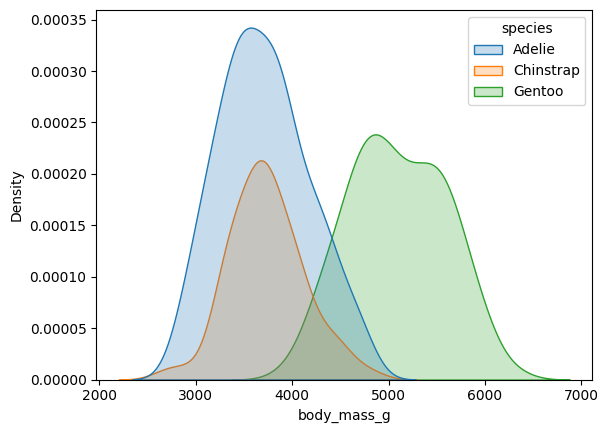

In [6]:
sns.kdeplot(penguins, x="body_mass_g", hue="species", fill=True)

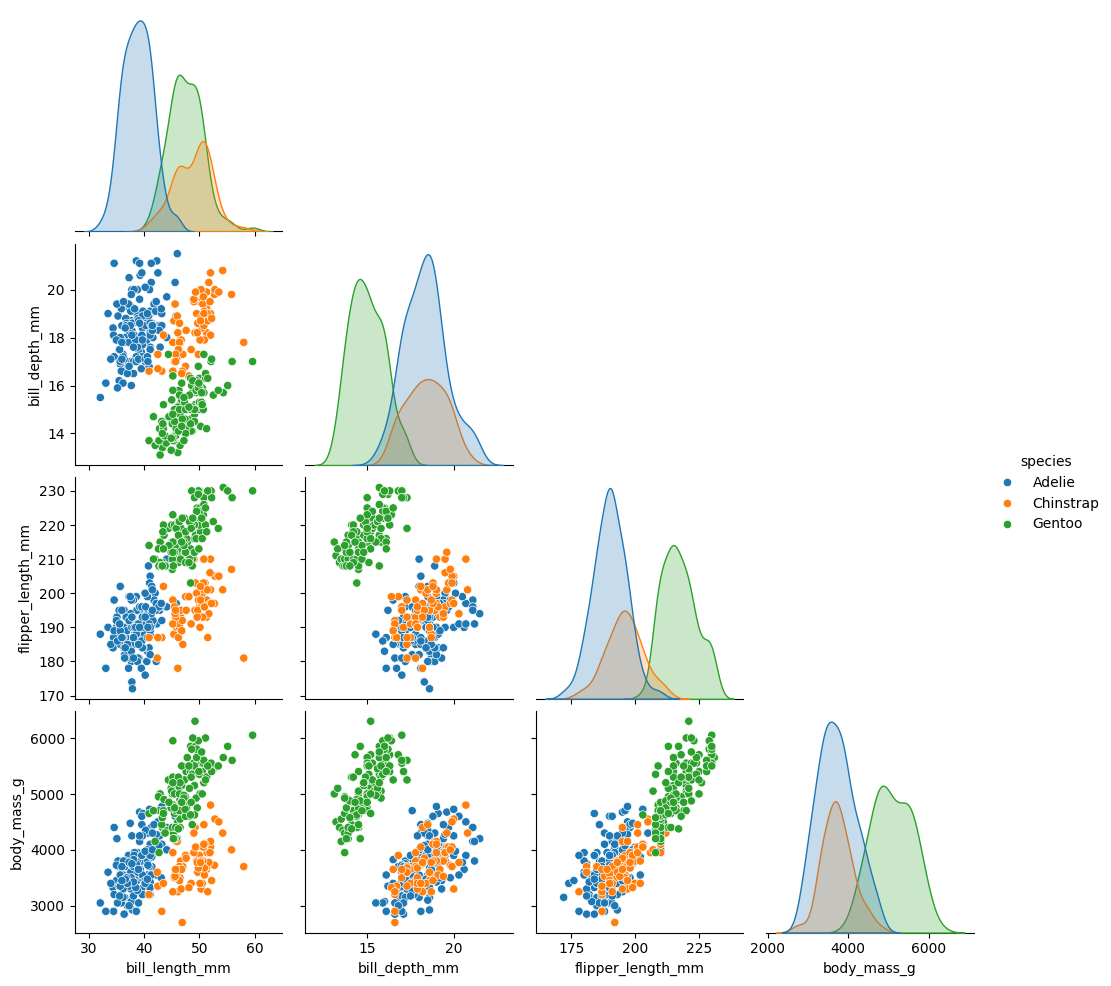

In [7]:
sns.pairplot(penguins, hue="species", corner = True)

In [8]:
duckdb.sql("""
SELECT species, count(species)
FROM penguins
GROUP BY species
""").df()

,species,count(species)
0,Adelie,146
1,Chinstrap,68
2,Gentoo,119


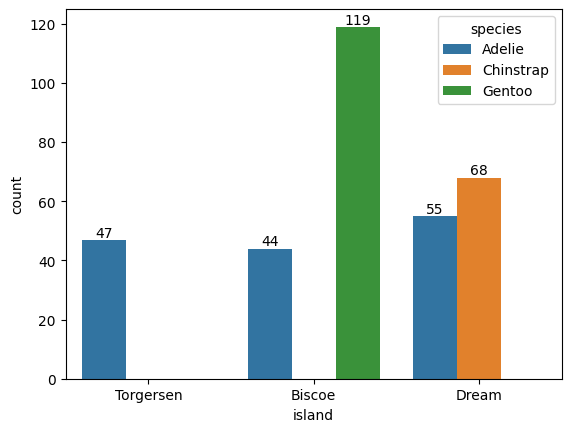

In [9]:
penguin_quantity = sns.countplot(penguins, x="island", hue="species")

for container in penguin_quantity.containers:
    penguin_quantity.bar_label(container)

plt.show()

<Axes: xlabel='body_mass_g', ylabel='island'>

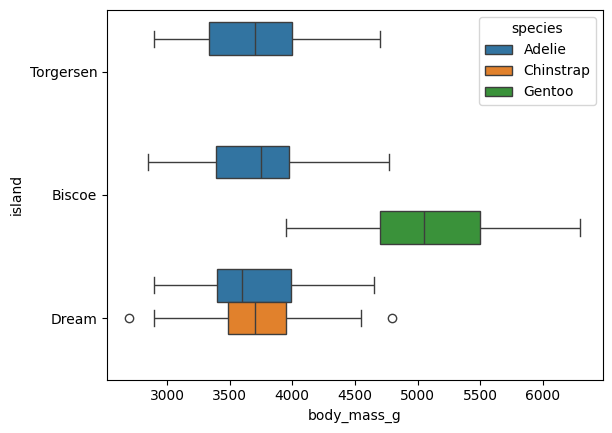

In [10]:
sns.boxplot(penguins, x ="body_mass_g", y = "island", hue = "species")

<Axes: >

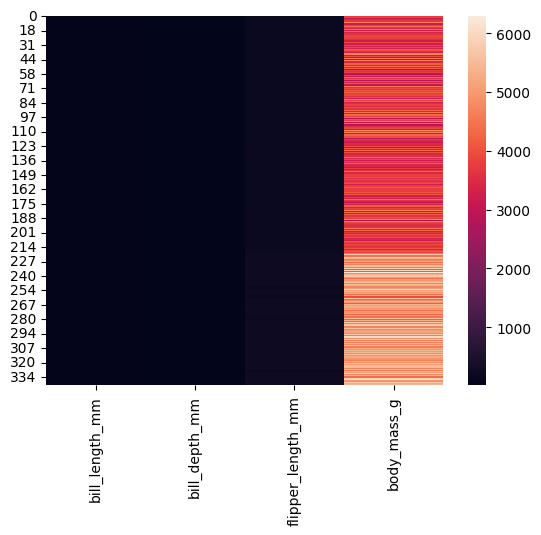

In [11]:
penguins_numeric = penguins.select_dtypes(include="number")

sns.heatmap(penguins_numeric)

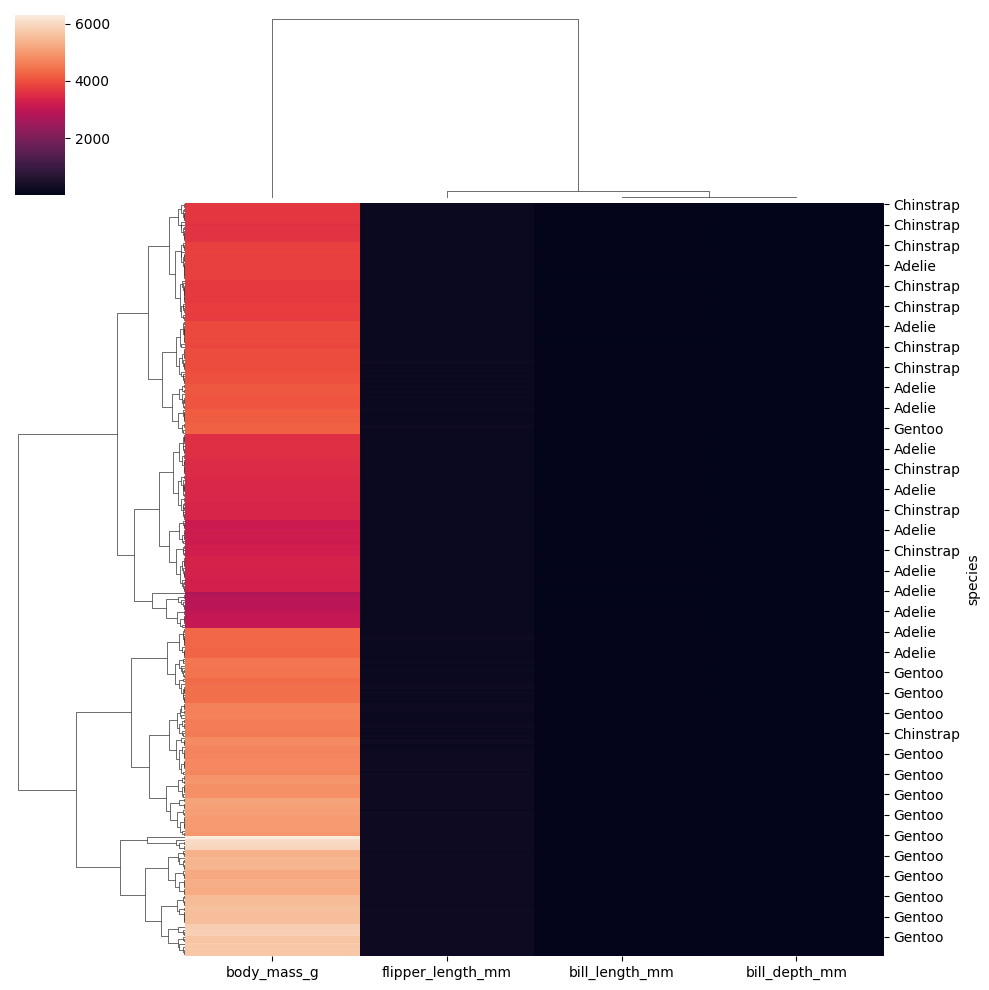

In [12]:
sns.clustermap(penguins[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g","species"]].set_index("species"))

## Statistiline testimine

<Axes: xlabel='body_mass_g', ylabel='Density'>

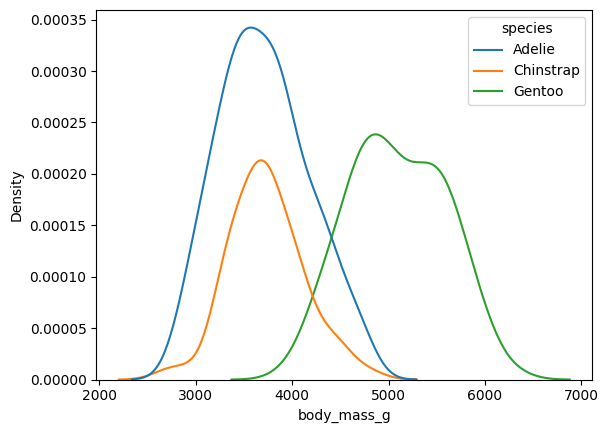

In [14]:
sns.kdeplot(penguins, x = "body_mass_g", hue = "species")

In [ ]:
# Statistiline testimine

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    duckdb.sql("SELECT body_mass_g FROM penguins WHERE species = 'Adelie'").df()["body_mass_g"],
    duckdb.sql("SELECT body_mass_g FROM penguins WHERE species = 'Chinstrap'").df()["body_mass_g"],
    alternative='two-sided'
)
print(f"{p:.15f}")

0.547616848670757


## Ennustamine (masinõpe)

In [17]:
!pip install statsmodels
import statsmodels.formula.api as smf

penguins["sex_binary"] = (penguins["sex"] == "Male").astype(int)

model = smf.logit("sex_binary ~ body_mass_g + flipper_length_mm", data=penguins).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.558531
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             sex_binary   No. Observations:                  333
Model:                          Logit   Df Residuals:                      330
Method:                           MLE   Df Model:                            2
Date:                Tue, 14 Apr 2026   Pseudo R-squ.:                  0.1942
Time:                        14:42:27   Log-Likelihood:                -185.99
converged:                       True   LL-Null:                       -230.80
Covariance Type:            nonrobust   LLR p-value:                 3.449e-20
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.0868      2.662      2.662      0.008       1.869      12.305
body_mas

In [18]:
new_data = pd.DataFrame({
    "body_mass_g": [4000, 3500, 5000],
    "flipper_length_mm": [200, 185, 210]
})
new_data["pred_prob"] = model.predict(new_data)
new_data["pred_class"] = (new_data["pred_prob"] > 0.5).astype(int)
new_data

,body_mass_g,flipper_length_mm,pred_prob,pred_class
0,4000,200,0.392569,0
1,3500,185,0.394442,0
2,5000,210,0.804225,1
